In [1]:
from google.colab import files
uploaded = files.upload()

Saving Letters.zip to Letters.zip


In [4]:
!unzip Letters.zip -d /content/
base_dir = "/content/Letters"

Archive:  Letters.zip
   creating: /content/Letters/
   creating: /content/Letters/0/
  inflating: /content/Letters/0/0_1.jpg  
  inflating: /content/Letters/0/0_10.jpg  
  inflating: /content/Letters/0/0_11.jpg  
  inflating: /content/Letters/0/0_12.jpg  
  inflating: /content/Letters/0/0_2.jpg  
  inflating: /content/Letters/0/0_3.jpg  
  inflating: /content/Letters/0/0_4.jpg  
  inflating: /content/Letters/0/0_5.jpg  
  inflating: /content/Letters/0/0_6.jpg  
  inflating: /content/Letters/0/0_7.jpg  
  inflating: /content/Letters/0/0_8.jpg  
  inflating: /content/Letters/0/0_9.jpg  
   creating: /content/Letters/1/
  inflating: /content/Letters/1/0_12.jpg  
  inflating: /content/Letters/1/1_1.jpg  
  inflating: /content/Letters/1/1_10.jpg  
  inflating: /content/Letters/1/1_11.jpg  
  inflating: /content/Letters/1/1_2.jpg  
  inflating: /content/Letters/1/1_3.jpg  
  inflating: /content/Letters/1/1_4.jpg  
  inflating: /content/Letters/1/1_5.jpg  
  inflating: /content/Letters/1/1_6

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 17ms/step - accuracy: 0.9546 - loss: 0.1473
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.9846 - loss: 0.0508
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9883 - loss: 0.0373
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9916 - loss: 0.0273
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9927 - loss: 0.0218
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - accuracy: 0.9942 - loss: 0.0179
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9948 - loss: 0.0155
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.9954 - loss: 0.0136
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9963 - loss: 0.0104
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 19ms/step - accuracy: 0.9964 - loss: 0.0103
Точність MNIST test: 0.9918000102043152
Точність

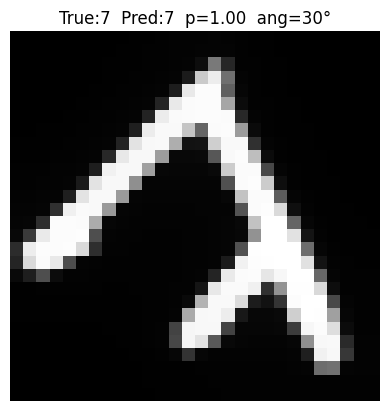

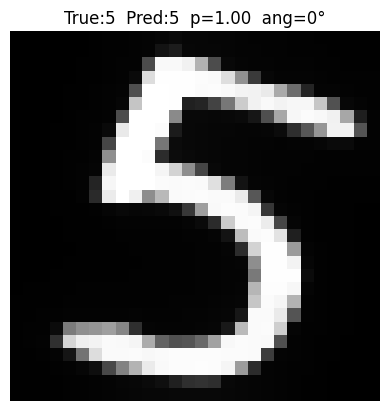

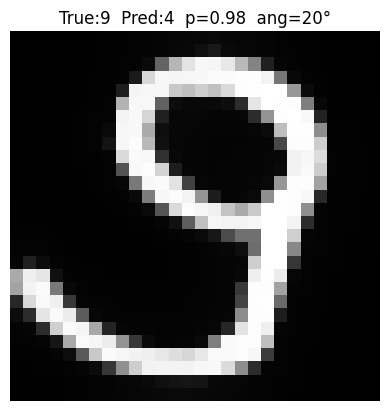

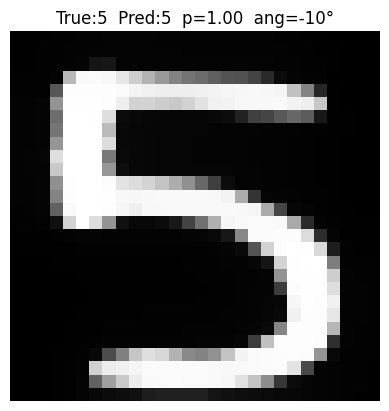

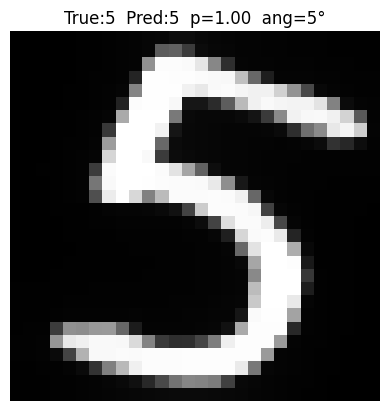

In [5]:
import os, glob, random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from skimage.restoration import denoise_tv_chambolle

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = (x_train / 255.0)[..., np.newaxis]
x_test  = (x_test  / 255.0)[..., np.newaxis]

model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Conv2D(32, 3, activation="relu"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(64, 3, activation="relu"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation="softmax")
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.fit(x_train, y_train, epochs=10, verbose=1)

print("Точність MNIST test:", model.evaluate(x_test, y_test, verbose=0)[1])

def preprocess_photo(path):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        digit = cv2.resize(gray, (28, 28), interpolation=cv2.INTER_AREA).astype(np.float32) / 255.0
        digit = 1.0 - digit
        return denoise_tv_chambolle(digit, weight=0.05)

    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)
    digit = thresh[y:y+h, x:x+w]

    digit = cv2.morphologyEx(digit, cv2.MORPH_CLOSE, np.ones((2, 2), np.uint8))
    digit = cv2.copyMakeBorder(digit, 28, 28, 28, 28, cv2.BORDER_CONSTANT, value=0)
    digit = cv2.resize(digit, (28, 28), interpolation=cv2.INTER_AREA).astype(np.float32) / 255.0

    ys, xs = np.where(digit > 0.1)
    if xs.size and ys.size:
        shift_x = int(round(14 - xs.mean()))
        shift_y = int(round(14 - ys.mean()))
        M = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
        digit = cv2.warpAffine(digit, M, (28, 28), borderValue=0)

    return denoise_tv_chambolle(digit, weight=0.05)


def rotate_image(img, angle):
    M = cv2.getRotationMatrix2D((14, 14), angle, 1.0)
    return cv2.warpAffine(img, M, (28, 28), borderValue=0)

def predict_with_rotation(img, angles=range(-30, 31, 5)):
    best_p, best_d, best_a = -1.0, None, 0
    for a in angles:
        rot = rotate_image(img, a)
        probs = model.predict(rot.reshape(1, 28, 28, 1), verbose=0)[0]
        d = int(np.argmax(probs))
        p = float(np.max(probs))
        if p > best_p:
            best_p, best_d, best_a = p, d, a
    return best_d, best_p, best_a

images, labels = [], []
base_dir = "/content/Letters"

for folder in os.listdir(base_dir):
    folder_path = os.path.join(base_dir, folder)
    if os.path.isdir(folder_path) and folder.isdigit():
        for img_path in glob.glob(os.path.join(folder_path, "*.*")):
            images.append(preprocess_photo(img_path))
            labels.append(int(folder))

images = np.array(images, dtype=np.float32)
labels = np.array(labels, dtype=int)

preds = np.array([predict_with_rotation(img)[0] for img in images], dtype=int)
acc_photos = np.mean(preds == labels)
print("Точність для фото з поворотами:", round(acc_photos * 100, 2), "%")

k = min(5, len(images))
for idx in random.sample(range(len(images)), k):
    img = images[idx]
    pred, prob, ang = predict_with_rotation(img)
    plt.imshow(img, cmap="gray")
    plt.title(f"True:{labels[idx]}  Pred:{pred}  p={prob:.2f}  ang={ang}°")
    plt.axis("off")
    plt.show()